In [1]:
from src.Utils import plot_traces, save_results, get_means
from src.Dataset import dataset_TES
#from src.LoadAutoencoder import load_autoencoder
from src.ExistingAlgorithms import max_value, area, sklearn_available
from src.ParametricUMAP import load_pumap
from src.GaussianMixture import gaussian_mixture

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

import umap

import torch
import numpy as np
import matplotlib.pyplot as plt

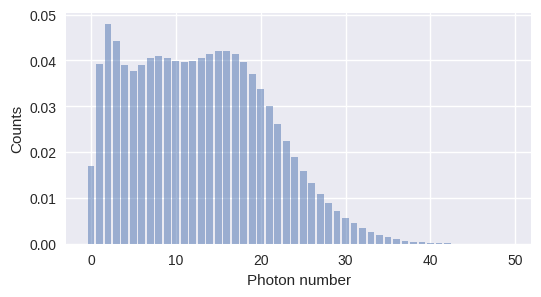

(30550, 350)

In [2]:
weights = [1.00000000e+00, 8.67567149e-01, 5.11893733e-01, 4.64791825e-01, 
           1.95257413e-01, 3.48166360e-01,1.24623185e-13, 3.89968505e-14, 3.60043421e-01]

#weights = [0.00047741680462955936, 0.0004709397517675953, 0.0010445432139792974, 0.002944736179232991, 0.04200636206501693, 0.0678533708472783, 0.27526434576344766, 0.1658809085942664, 0.5344563925233353, 0.4171218544172766, 1.083876657430484e-16, 0.2504288272925047, 0.9999999999999999]

weights = [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 
           5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 
           0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]

path_save = 'src/Results TES (Uniform)/Low Dimension'
path_results = 'src/Results TES (Uniform)'

data_train, data_test, expected_prob, db_train, db_test = dataset_TES(weights = weights,
                                                                signal_size = 8192,
                                                                interval = [0,350],#270],
                                                                order_dB = False,
                                                                normalize = True,
                                                                plot_expected = True,
                                                                plot_traces = False,
                                                                n_photon_number = 50,
                                                                return_db=True)

data_train.shape

In [3]:
X_l_tSNE = sklearn_available(data_train, data_test, path_save, TSNE,n_components=1, perplexity = 450)

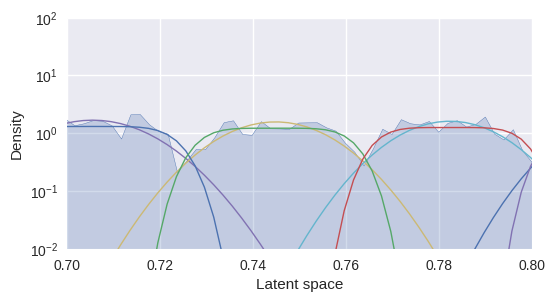

In [17]:
name_method = 'tSNE 1D genGauss'
gm = gaussian_mixture(X_l_tSNE,
                      data_test,
                      number_cluster = 27,
                      cluster_iter = 5,
                      tol = 1e-3,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.005, 
                plot_gaussians=True,
                plot_gen_gauss = True,
                xlim = (0.7,0.8))#(0.105,0.163))#(0.16,0.22))